In [3]:
!kaggle competitions download -c playground-series-s5e11 

  0%|                                               | 0.00/19.3M [00:00<?, ?B/s]
100%|███████████████████████████████████████| 19.3M/19.3M [00:00<00:00, 998MB/s]


In [ ]:
!unzip -o playground-series-s5e11.zip 

Archive:  playground-series-s5e11.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
!rm playground-series-s5e11.zip 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## load update

In [22]:
train_df = pd.read_csv('train.csv') 
test_df = pd.read_csv('test.csv')
submission_df = pd.read_csv('sample_submission.csv')

## eda


In [23]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [24]:
test_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [25]:
train_df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442236,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [26]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [27]:
train_df.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

## endcodeing

In [31]:
#show  train data is object type
train_df.dtypes[train_df.dtypes == 'object']

gender               object
marital_status       object
education_level      object
employment_status    object
loan_purpose         object
grade_subgrade       object
dtype: object

In [32]:
# show the unique values in object type columns
for col in train_df.dtypes[train_df.dtypes == 'object'].index:
    print(f"{col}: {train_df[col].unique()}")  
    

gender: ['Female' 'Male' 'Other']
marital_status: ['Single' 'Married' 'Divorced' 'Widowed']
education_level: ['High School' "Master's" "Bachelor's" 'PhD' 'Other']
employment_status: ['Self-employed' 'Employed' 'Unemployed' 'Retired' 'Student']
loan_purpose: ['Other' 'Debt consolidation' 'Home' 'Education' 'Vacation' 'Car'
 'Medical' 'Business']
grade_subgrade: ['C3' 'D3' 'C5' 'F1' 'D1' 'D5' 'C2' 'C1' 'F5' 'D4' 'C4' 'D2' 'E5' 'B1'
 'B2' 'F4' 'A4' 'E1' 'F2' 'B4' 'E4' 'B3' 'E3' 'B5' 'E2' 'F3' 'A5' 'A3'
 'A1' 'A2']


In [33]:
# endcoding
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in train_df.dtypes[train_df.dtypes == 'object'].index:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le
    

In [35]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  int64  
 7   marital_status        593994 non-null  int64  
 8   education_level       593994 non-null  int64  
 9   employment_status     593994 non-null  int64  
 10  loan_purpose          593994 non-null  int64  
 11  grade_subgrade        593994 non-null  int64  
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 58.9 MB


In [36]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,1.0
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,0.0
2,2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,1.0
3,3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25,1.0
4,4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,1.0


In [39]:
label_encoders = {}
for col in test_df.dtypes[test_df.dtypes == 'object'].index:
    le = LabelEncoder()
    test_df[col] = le.fit_transform(test_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

In [40]:
test_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,0,2,1,0,6,19
1,593995,46626.39,0.093,732,15492.25,12.85,0,1,2,0,6,10
2,593996,54954.89,0.367,611,3796.41,13.29,1,2,0,0,2,15
3,593997,25644.63,0.110,671,6574.30,9.57,0,2,0,0,2,12
4,593998,25169.64,0.081,688,17696.89,12.80,0,1,4,0,0,10


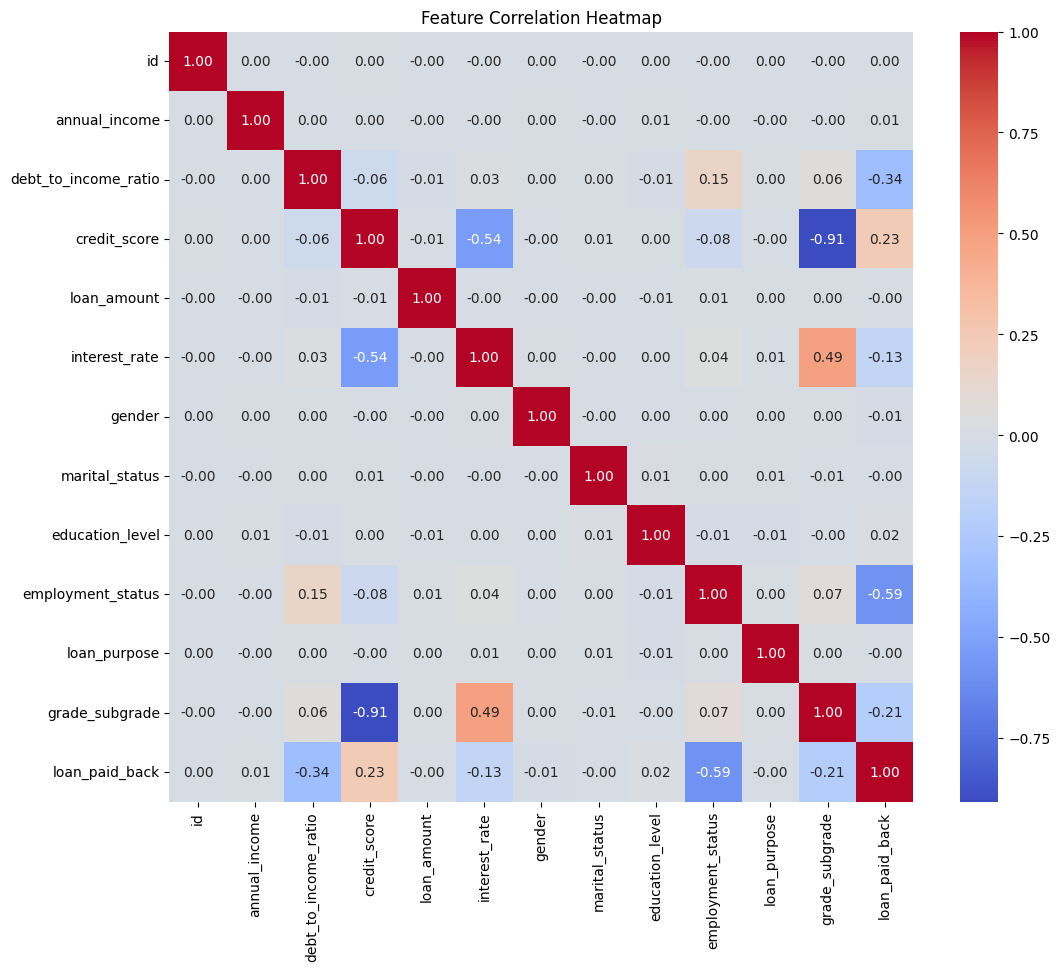

In [37]:
#plot correlation heatmap
plt.figure(figsize=(12,10))
correlation_matrix = train_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [38]:
# splitting dataset
X = train_df.drop(['id', 'loan_paid_back'], axis=1)
y = train_df['loan_paid_back']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

Accuracy: 0.9023897507554778
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.60      0.71     23997
         1.0       0.91      0.98      0.94     94802

    accuracy                           0.90    118799
   macro avg       0.89      0.79      0.83    118799
weighted avg       0.90      0.90      0.90    118799

Confusion Matrix:
 [[14386  9611]
 [ 1985 92817]]


In [43]:
#create submission file baseline
test_X = test_df.drop(['id'], axis=1)
test_pred = model.predict(test_X)
submission_df['loan_paid_back'] = test_pred
submission_df.to_csv('submission_baseline.csv', index=False)

In [45]:
submission_df.head()

,id,loan_paid_back
0,593994,1.0
1,593995,1.0
2,593996,0.0
3,593997,1.0
4,593998,1.0


In [46]:
!kaggle competitions submit -c playground-series-s5e11 -f submission_baseline.csv -m "baseline submission"

100%|███████████████████████████████████████| 2.67M/2.67M [00:02<00:00, 978kB/s]
Successfully submitted to Predicting Loan Payback